# K-nearest Neighbor (KNN)

El algoritmo **K-Nearest Neighbors (KNN)** es un método de aprendizaje supervisado utilizado tanto para clasificación como para regresión. Se basa en la premisa de que los datos similares tienden a estar cerca unos de otros en el espacio de características.

---

### **¿Cómo funciona?**
1. **Definir "K"**: Se elige un número de vecinos \( K \), que determinará cuántos puntos cercanos se considerarán para tomar una decisión.
2. **Medir la distancia**: Para un nuevo punto de datos, se calcula su distancia con todos los puntos de entrenamiento. Comúnmente, se usa la distancia euclidiana:
  $d(A, B) = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$

3. **Identificar los K vecinos más cercanos**: Se ordenan los puntos de entrenamiento según su distancia con el nuevo punto y se seleccionan los \( K \) más cercanos.
4. **Hacer una predicción**:
   - **Clasificación**: Se toma la clase más frecuente entre los vecinos seleccionados (votación mayoritaria).
   - **Regresión**: Se toma el promedio de los valores de los vecinos.

---


### **Ventajas**
- Fácil de entender e implementar. 
- Puede adaptarse a distintos tipos de datos.

### **Desventajas**
- Se vuelve lento con grandes volúmenes de datos, porque cada predicción implica calcular distancias con todos los puntos.  
- El performance puede verse afectado si las features tienen escalas muy amplias/variadas (requiere normalización).  
- La elección del valor de \( K \) puede afectar el desempeño del modelo.

---

### **Cuándo usar KNN**
- Cuando los datos tienen una estructura clara y pocos atributos.
- En problemas de clasificación con clases bien separadas.
- Cuando no se necesita un modelo en tiempo real y se pueden calcular distancias en cada predicción.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


In [3]:
# Cargar el dataset
iris = datasets.load_iris()

# Convertirlo en un DataFrame de Pandas
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Mostrar las primeras filas
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


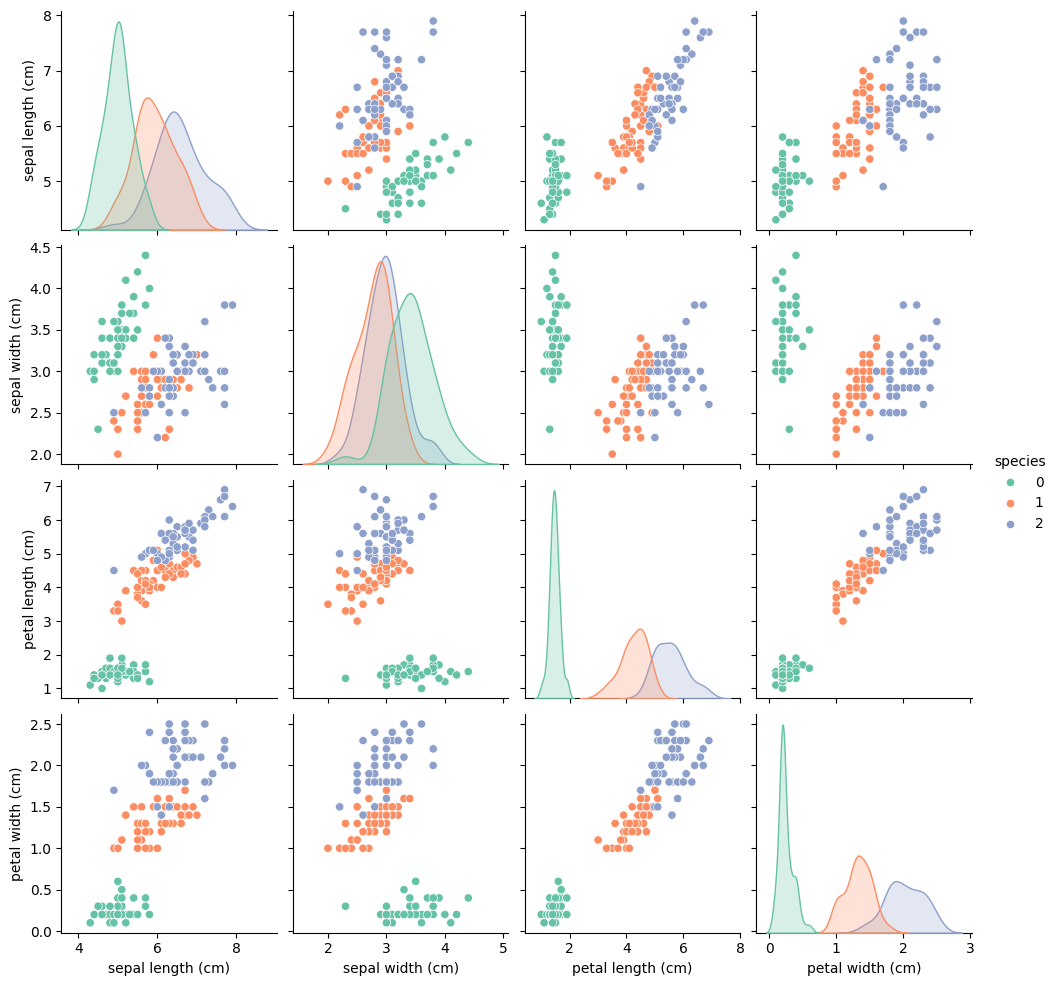

In [4]:
# Ver información del dataset
df.info()

# Ver distribución de clases
df['species'].value_counts()

# Visualización con pares de variables
sns.pairplot(df, hue='species', palette='Set2')
plt.show()

In [5]:
# Separar características (X) y etiquetas (y)
X = iris.data
y = iris.target
print(X,y)
print(type(X),type(y))


[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [6]:
# Dividir el dataset en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Normalización de los datos 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### ¿Cómo definimos el mejor K?

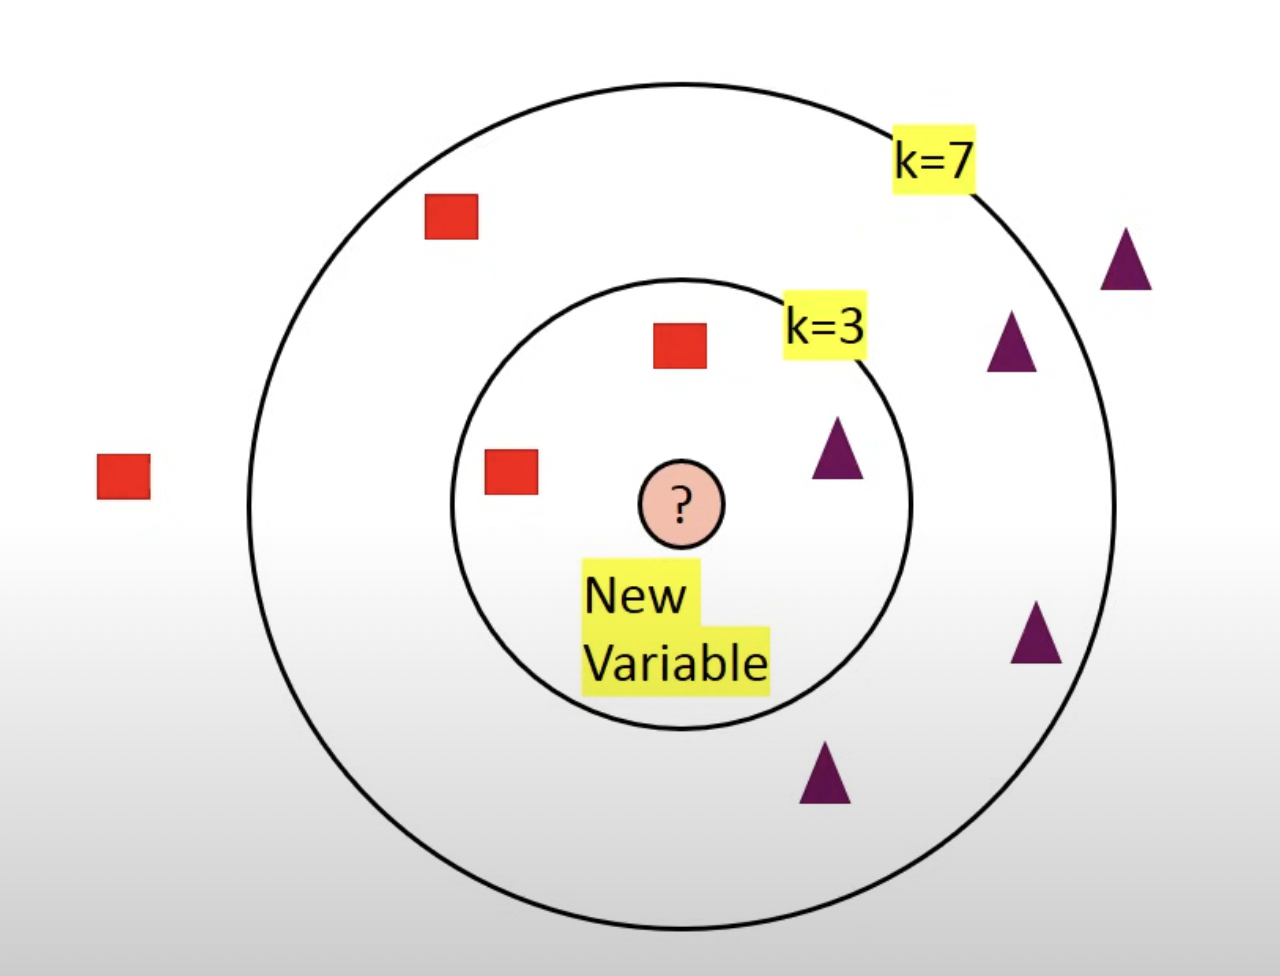

- KNN está basado en qué tan similares son los puntos más cercanos (feature similarity)
- Algunas literaturas sugieren usar Sqrt(n) para definir K.
- Según nuestra Y, podemos sugerir utilizar un número K impar para evitar confusiones entre clases parejas de data


In [8]:
print(X_train, len(X_train))

[[-0.4134164  -1.46200287 -0.09951105 -0.32339776]
 [ 0.55122187 -0.50256349  0.71770262  0.35303182]
 [ 0.67180165  0.21701605  0.95119225  0.75888956]
 [ 0.91296121 -0.02284379  0.30909579  0.2177459 ]
 [ 1.63643991  1.41631528  1.30142668  1.70589097]
 [-0.17225683 -0.26270364  0.19235097  0.08245999]
 [ 2.11875905 -0.02284379  1.59328871  1.16474731]
 [-0.29283662 -0.02284379  0.36746819  0.35303182]
 [-0.89573553  1.17645543 -1.44207638 -1.40568508]
 [ 2.23933883 -0.50256349  1.65166111  1.0294614 ]
 [-0.05167705 -0.74242333  0.13397857 -0.32339776]
 [-0.77515575  0.93659559 -1.44207638 -1.40568508]
 [-1.01631531  1.17645543 -1.50044878 -1.27039917]
 [-0.89573553  1.89603497 -1.15021435 -1.13511325]
 [-1.01631531 -2.42144225 -0.21625586 -0.32339776]
 [ 0.55122187 -0.74242333  0.60095781  0.75888956]
 [-1.25747488  0.93659559 -1.15021435 -1.40568508]
 [-1.01631531 -0.02284379 -1.32533157 -1.40568508]
 [-0.89573553  0.69673574 -1.26695916 -0.99982734]
 [-0.29283662 -0.74242333  0.19

In [18]:
# Probar diferentes valores de K
accuracies = []
cv_scores = []
k_values = range(1, 41)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, p=2, metric='euclidean')
    knn.fit(X_train, y_train)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(np.mean(scores))
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

El valor de p define el tipo de distancia:

- p = 1 → Distancia Manhattan (metric='manhattan') (generalmente se usa cuando tengamos outliers)
- p = 2 → Distancia Euclidiana (la más común)
- p = 3 → una versión más “acentuada” de la euclidiana (metric='minkowski'). Acentuado porque las diferencias grandes pesan mucho más en la distancia
- p → ∞ → distancia Chebyshev (máxima diferencia), (metric='chebyshev', pero no se usa infinito en p sino solo se omite el hiperparámetro)

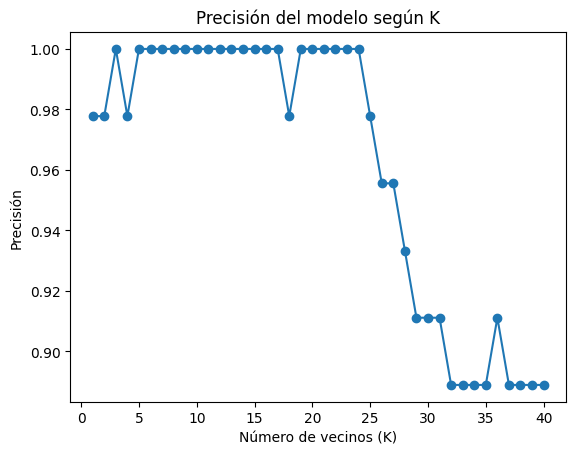

In [19]:
# Graficar la precisión vs. K
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('Número de vecinos (K)')
plt.ylabel('Precisión')
plt.title('Precisión del modelo según K')
plt.show()

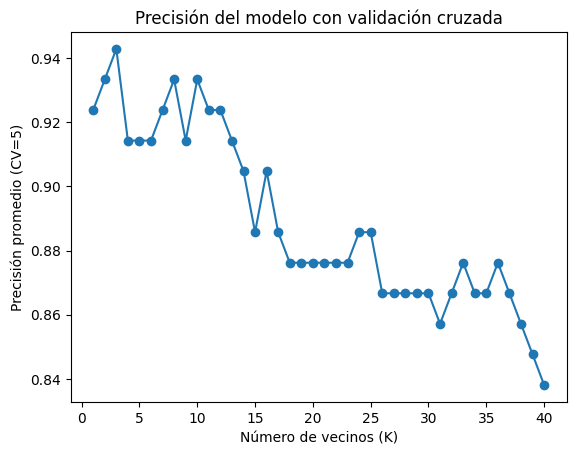

Mejor valor de K según CV=5: 3


In [20]:
# Graficamos los resultados
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel('Número de vecinos (K)')
plt.ylabel('Precisión promedio (CV=5)')
plt.title('Precisión del modelo con validación cruzada')
plt.show()

# Mejor K basado en la validación cruzada
best_k = k_values[np.argmax(cv_scores)]
print(f"Mejor valor de K según CV=5: {best_k}")

In [14]:
# Comparemos K's
import math
print(math.sqrt(len(y_test)))

6.708203932499369


In [21]:
# Definir el modelo con K=3
knn = KNeighborsClassifier(n_neighbors=3, p=2, metric='euclidean')
knn.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=3)

In [22]:
# Predicción en el conjunto de prueba
y_pred = knn.predict(X_test)


In [23]:
# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:")
print(conf_matrix)

# Reporte de clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

# Precisión del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión del modelo: {accuracy:.2f}")

Matriz de Confusión:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Precisión del modelo: 1.00


- KNN puede ser un buen modelo para datos bien estructurados como **Iris**.
- La elección del valor de **K** afecta el rendimiento; 
- ¿Qué pasa con un K más grande vs uno más pequeño?
- La normalización de datos mejora el rendimiento de KNN.
- Se puede probar con más técnicas como validación cruzada y ajuste de hiperparámetros para mejorar resultados.
